In [1]:
from pathlib import Path
from typing import Any
import numpy as np
import optuna
from dataclasses import dataclass

from my_types import Quat, ScalarBatch, Vec3Batch, QuatBatch
from io_csv import load_gyro_base, load_ref, load_acc, load_mag, load_grav_ref, load_acc_lin_ref, read_best_exp2_from_log
from pipelines import generate_m_ref_world_h_unit, integrate_gyro_acc_mag
from pipelines import check_integration_integrate_gyro_acc_mag
from evaluation import calc_angle_err, print_err_status, save_err_csv, plot_err_from_csv, plot_err_colored_by_weight
from evaluation import save_estimated_vec3_csv, evaluate_estimated_vec3_autosign, calc_vec3_direction_angle_err
from resample import find_stable_start_idx, cut_sample
from autotune import auto_setup_imu_frame, quasi_static_detector, suggest_fixed_gate_sigma
from optuna_exp_3 import exp_3_1, exp_3_2, exp_3_3, exp_3_4, exp_3_5, exp_3_6
from Tee import Tee

SIGMA_FLOOR: float = 1e-3
EPS: float = 1e-9

In [2]:
sample_1: str = "data01_21:08_oct_07_2025_5min"
sample_2: str = "data02_21:23_oct_07_2025_9min"
sample_3: str = "data03_21:41_oct_07_2025_13min"
sample_4: str = "data04_18:52_oct_08_2025_96min"

sample: str = sample_1

root: Path = Path.cwd().parent
run_dir: Path = root / "data" / sample

ori_path: Path = run_dir / "Orientation.csv"
gyro_path: Path = run_dir / "Gyroscope.csv"
acc_path: Path = run_dir / "AccelerometerUncalibrated.csv"
mag_path: Path = run_dir / "Magnetometer.csv"
grav_path: Path = run_dir / "Gravity.csv"
acc_lin_path: Path = run_dir / "Accelerometer.csv"

for p in [ori_path, gyro_path, acc_path, mag_path, grav_path, acc_lin_path]:
        if not p.exists():
                raise FileNotFoundError(f"File not found: {p}")

out_dir: Path = root / "output" / sample
out_dir.mkdir(parents=True, exist_ok=True)

path_log: Path = out_dir / "04_exp4_log.txt"
path_err_1: Path = out_dir / "04_exp4-1_angle_err.csv"
path_err_2: Path = out_dir / "04_exp4-2_angle_err.csv"
path_err_3: Path = out_dir / "04_exp4-3_angle_err.csv"
path_err_4: Path = out_dir / "04_exp4-4_angle_err.csv"
path_err_5: Path = out_dir / "04_exp4-5_angle_err.csv"
path_err_6: Path = out_dir / "04_exp4-6_angle_err.csv"

path_plot: Path = out_dir / "04_exp4_plot.png"
path_plot_weight: Path = out_dir / "04_exp4_plot_weight.png"

path_est_grav: Path = out_dir / "04_exp4_grav_est.csv"
path_est_acc: Path = out_dir / "04_exp4_acc_lin_est.csv"


for p in [path_log, path_err_1, path_err_2, path_err_3, path_err_4, path_err_5, path_err_6,
          path_plot, path_plot_weight, path_est_grav, path_est_acc]:
        if p.is_file():
                p.unlink()

In [3]:
with Tee(path_log):
        t_src_gyro, w_src_gyro, dt, t_new, w_avg_gyro = load_gyro_base(gyro_path)

        q_ref_interp = load_ref(ori_path, t_new)
        q_ref_interp /= np.linalg.norm(q_ref_interp, axis=1, keepdims=True)

        g_ref_interp = load_grav_ref(grav_path, t_new)
        a_lin_ref_interp = load_acc_lin_ref(acc_lin_path, t_new)

        idx_cut: int = find_stable_start_idx(dt, w_avg_gyro, q_ref_interp,
                                             sample_window=1000, threshold=0.5, sample_hz=100,
                                             consecutive=3, min_cut_second=10, max_cut_second=30)
        t_cut: int = idx_cut / 100
        a_src_interp = load_acc(acc_path, t_new)
        m_src_interp = load_mag(mag_path, t_new)
        [dt, t_new, w_avg_gyro, q_ref_interp,
         a_src_interp, m_src_interp,
         g_ref_interp, a_lin_ref_interp] = cut_sample(idx_cut,
                                                      [dt, t_new, w_avg_gyro, q_ref_interp,
                                                       a_src_interp, m_src_interp,
                                                       g_ref_interp, a_lin_ref_interp])



[START] 2026-03-16 13:42:24.143

[INFO] Stabilization detected too early (< min_cut), applying min_cut=10s policy

[END] 2026-03-16 13:42:24.816




In [4]:
with Tee(path_log):
        q0: Quat = q_ref_interp[0].copy()
        g0: float = 9.80665
        a_src_interp, g_world_unit = auto_setup_imu_frame(q_ref_interp, w_avg_gyro, dt,
                                                          g0, a_src_interp)
        print("")

        m0: float = np.median(np.linalg.norm(m_src_interp, axis=1))
        m_ref_world_h_unit = generate_m_ref_world_h_unit(g0, g_world_unit, 5000,
                                                         q_ref_interp, a_src_interp, m_src_interp)
        
        best_quasi_static = quasi_static_detector(w_avg_gyro, a_src_interp, dt, g0,
                                                  w_thr=4, a_thr=4,
                                                  min_duration_s=0.5, smooth_win=5)
        print("")

        gyro_gate_sigma, acc_gate_sigma, mag_gate_sigma = suggest_fixed_gate_sigma(
                                                                w_avg_gyro, a_src_interp, m_src_interp,
                                                                g0, m0,
                                                                p_gyro=90, p_acc=90, p_mag=90, sigma_floor=SIGMA_FLOOR,
                                                                best_quasi_static=best_quasi_static)



[START] 2026-03-16 13:42:24.830

Detected accel unit in [m/s²]
Selected g_world_unit: [ 0  0 -1]

Best quasi static(start, end, length):  (2523, 3540, 1017)

Suggested gyro_sigma:  0.44791971689543864
Suggested acc_sigma:  2.908568806018301
Suggested mag_sigma:  6.850455808768257

[END] 2026-03-16 13:42:25.825




In [6]:
# exp 4-0: test

with Tee(path_log):
        [q_est_00, g_body_est_00, a_lin_est_00,
         weight_acc_00, weight_gyro_00, weight_mag_00]  = integrate_gyro_acc_mag(
                                                q0, w_avg_gyro, dt,
                                                0.003073946767883099, g0, g_world_unit,
                                                m0, m_ref_world_h_unit, 3.053091554041973,
                                                2.8671055, 3.0789585,
                                                30.1908042, 0.8,
                                                a_src_interp, m_src_interp)

        angle_err_00: ScalarBatch = calc_angle_err(q_est_00, q_ref_interp)
        print_err_status("[exp 4-00] Gyro guard test", angle_err_00)
        print("")
        print("")

        [weight_gyro_prop_01, w_use_01,
         q_est_01, g_body_est_01, a_lin_est_01,
         weight_acc_01, weight_gyro_01, weight_mag_01] = check_integration_integrate_gyro_acc_mag(
                                                                q0, w_avg_gyro, dt,
                                                                np.inf, np.inf,
                                                                np.inf, np.inf,
                                                                0.003073946767883099, g0, g_world_unit,
                                                                m0, m_ref_world_h_unit, 3.053091554041973,
                                                                2.8671055, 3.0789585,
                                                                30.1908042, np.inf,
                                                                a_src_interp, m_src_interp)
        angle_err_01: ScalarBatch = calc_angle_err(q_est_01, q_ref_interp)
        print_err_status("[exp 4-01] Gyro guard test", angle_err_01)
        print("")



[START] 2026-03-16 13:42:25.857

[exp 4-00] Gyro guard test angle error in rad — min/max/mean/p90
0.0027866181015508426 0.5548562426428996 0.038932489827991586 0.07559355968535549

[exp 4-00] Gyro guard test angle error in deg — min/max/mean/p90
0.15966145633362114 31.79092093992488 2.230667353079926 4.331191928341156


[exp 4-01] Gyro guard test angle error in rad — min/max/mean/p90
0.0027866181015508426 0.5847782864946023 0.039081338946933296 0.07565423484285555

[exp 4-01] Gyro guard test angle error in deg — min/max/mean/p90
0.15966145633362114 33.50532776703282 2.239195779379527 4.3346683587872015


[END] 2026-03-16 13:42:50.732




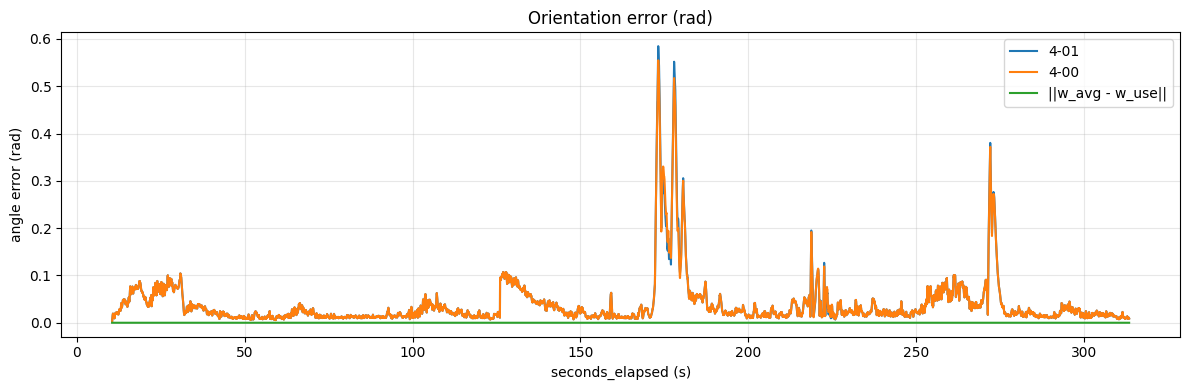

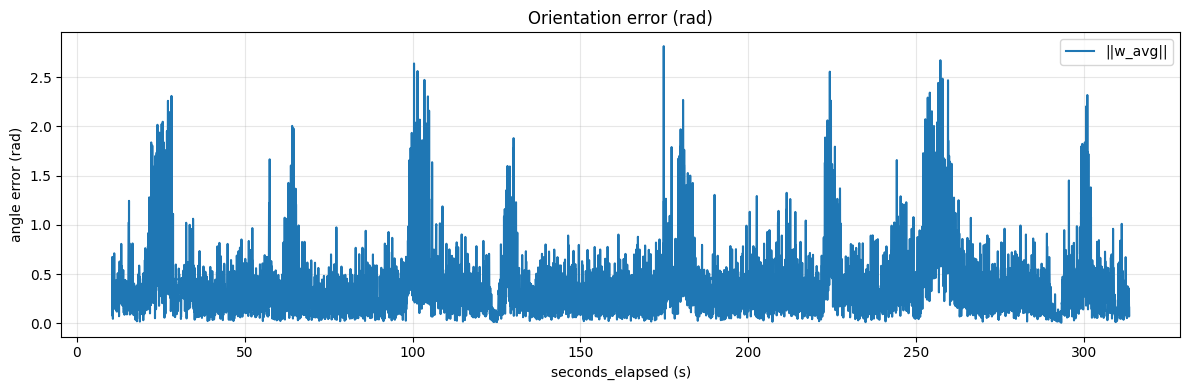

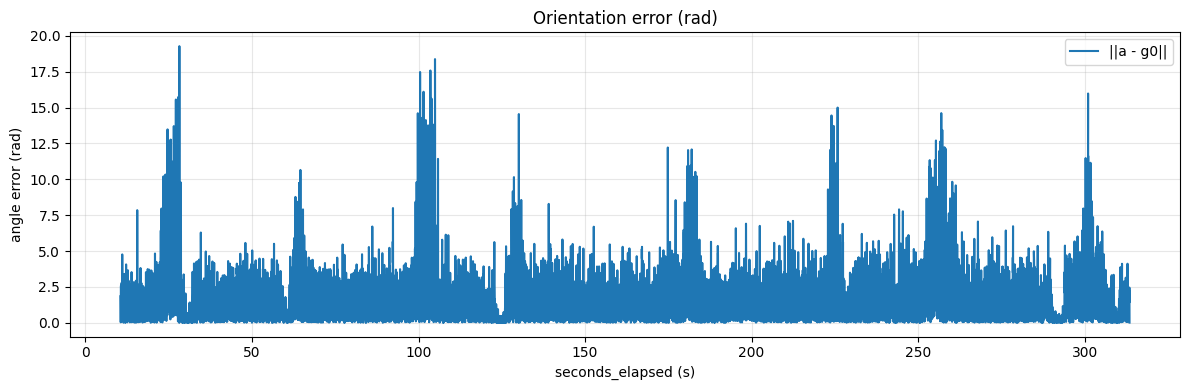

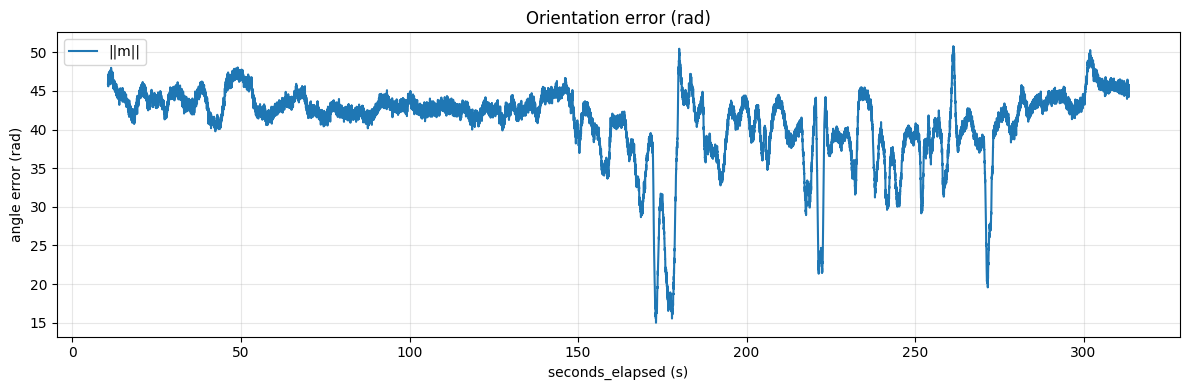

In [7]:
import matplotlib.pyplot as plt
from my_types import ScalarBatch

def plot_err(series: list[tuple[str, ScalarBatch]], dt: ScalarBatch) -> None:
        plt.figure(figsize=(12,4))
        plt.title("Orientation error (rad)")
        plt.xlabel("seconds_elapsed (s)")
        plt.ylabel("angle error (rad)")

        dt = np.asarray(dt, dtype=float).reshape(-1)
        for label, angle_err in series:
                angle_err = np.asarray(angle_err, dtype=float).reshape(-1)
                plt.plot(dt, angle_err, label=label)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
        plt.close()

dw: ScalarBatch = np.abs(np.linalg.norm(w_avg_gyro - w_use_01, axis=1))

plot_err([("4-01", angle_err_01),
          ("4-00", angle_err_00),
          ("||w_avg - w_use||", dw)], t_new)

w_raw_norm: ScalarBatch = np.abs(np.linalg.norm(w_avg_gyro, axis=1))
plot_err([("||w_avg||", w_raw_norm)], t_new)

a_norm: ScalarBatch = np.linalg.norm(a_src_interp, axis=1)
plot_err([("||a - g0||", np.abs(a_norm - g0))], t_new)

m_norm: ScalarBatch = np.abs(np.linalg.norm(m_src_interp, axis=1))
plot_err([("||m||", m_norm)], t_new)

suggest gyro_delta+sigma

def suggest_fixed_gyro_prop_delta_sigma(w: Vec3Batch, p: int = 95,
                                        sigma_floor: float = 1e-3) -> float:
    if len(w) < 2:
        return sigma_floor
    dw = w[1:] - w[:-1]
    dw_norm = np.linalg.norm(dw, axis=1)
    return max(sigma_floor, float(np.percentile(dw_norm, p)))

-------
suggest w_cap

def suggest_w_cap(w: Vec3Batch, p: int = 99) -> float:
    w_norm = np.linalg.norm(w, axis=1)
    return float(np.percentile(w_norm, p))

w_cap = 1.2 * p99(||w||)

-------
gyro_delta_sigma = p95(||w_i - w_{i-1}||)   # 데이터 기반 추천
gyro_theta_sigma = 20 deg                   # 일단 꺼두거나, 켜면 이 값
gyro_pre_integ_sigma = p95(pre_innov)       # 나중에 추가
w_cap = 8.0 rad/s                           # 또는 1.2 * p99(||w||)